Ryan Dunne C00263405

File Compression through Kmeans clustering using an image of SETU Carlow Campus
Following the example from PythonDataScienceHandbook
https://github.com/jakevdp/PythonDataScienceHandbook/blob/master/notebooks/05.11-K-Means.ipynb

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('ggplot')
import numpy as np

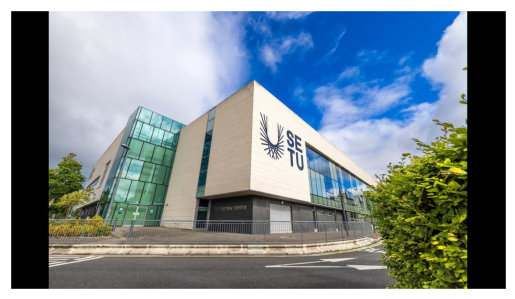

In [2]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Load the image into an array
carlowCampus = mpimg.imread("CarlowCampus.jpg")

# Plot the image
fig, ax = plt.subplots()
ax.imshow(carlowCampus)
ax.set_xticks([])
ax.set_yticks([])
plt.show()

In [3]:
carlowCampus.shape

(720, 1280, 3)

In [4]:
data = carlowCampus / 255.0  # use 0...1 scale
data = data.reshape(-1, 3)
data.shape

(921600, 3)

In [5]:
def plot_pixels(data, title, colors=None, N=20000): #Plot 20k pixels
    if colors is None:
        colors = data
    
    # choose a random subset
    rng = np.random.default_rng(0)
    i = rng.permutation(data.shape[0])[:N]
    colors = colors[i]
    R, G, B = data[i].T
    
    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
    ax[0].scatter(R, G, color=colors, marker='.')
    ax[0].set(xlabel='Red', ylabel='Green', xlim=(0, 1), ylim=(0, 1))

    ax[1].scatter(R, B, color=colors, marker='.')
    ax[1].set(xlabel='Red', ylabel='Blue', xlim=(0, 1), ylim=(0, 1))

    fig.suptitle(title, size=20);

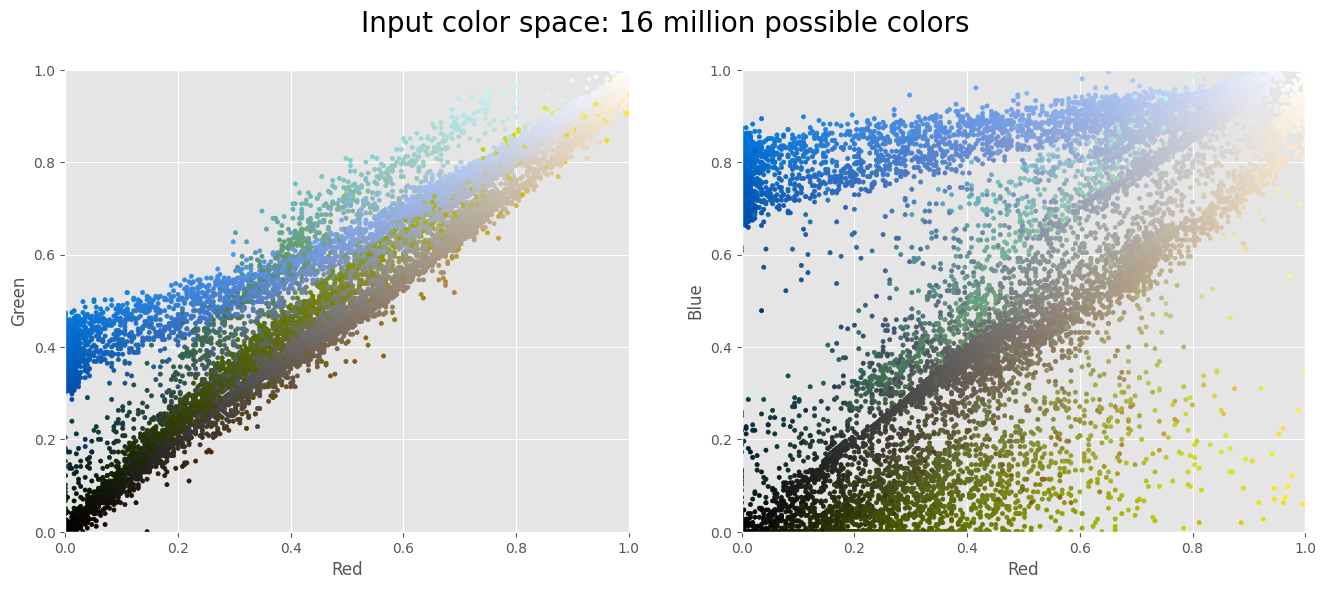

In [6]:
plot_pixels(data, title='Input color space: 16 million possible colors')

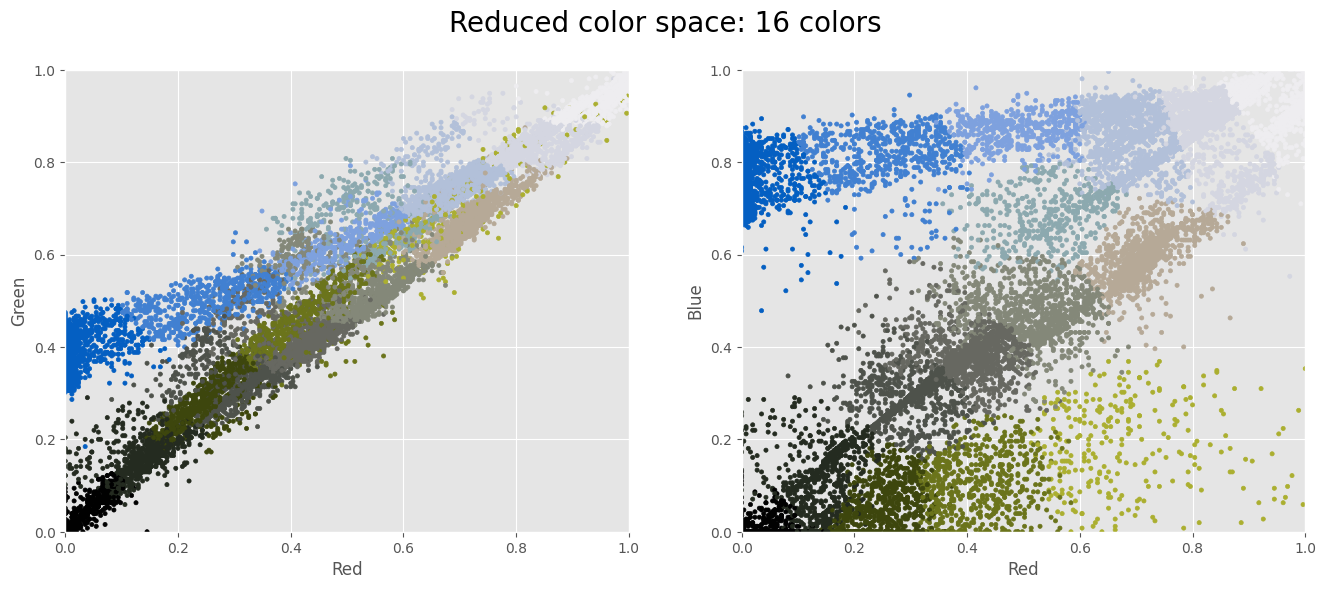

In [7]:
from sklearn.cluster import MiniBatchKMeans
kmeans = MiniBatchKMeans(16) #Creates 16 clusters each to represent a prominent colour
kmeans.fit(data)
new_colors = kmeans.cluster_centers_[kmeans.predict(data)]

plot_pixels(data, colors=new_colors,
            title="Reduced color space: 16 colors")

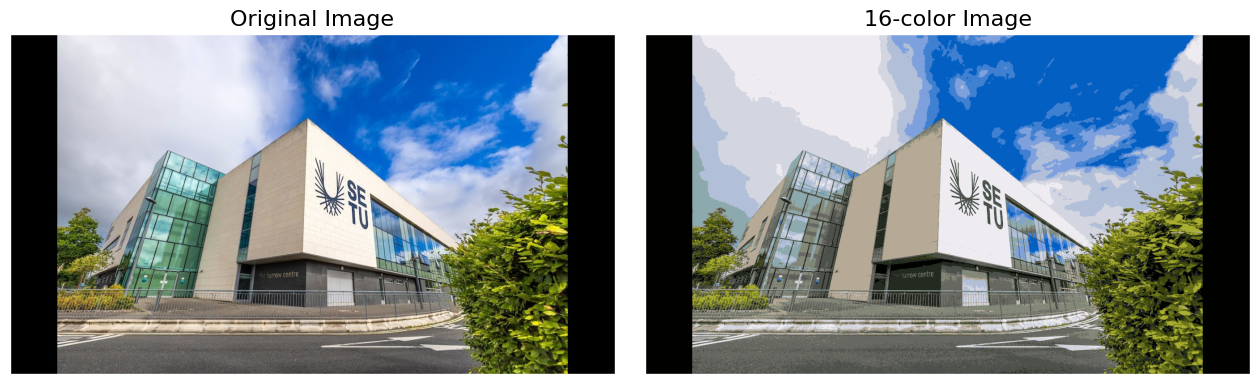

In [8]:
carlowCampusCompressed = new_colors.reshape(carlowCampus.shape)

fig, ax = plt.subplots(1, 2, figsize=(16, 6),
                       subplot_kw=dict(xticks=[], yticks=[]))
fig.subplots_adjust(wspace=0.05)
ax[0].imshow(carlowCampus)
ax[0].set_title('Original Image', size=16)
ax[1].imshow(carlowCampusCompressed)
ax[1].set_title('16-color Image', size=16);

plt.savefig("carlowCompressed.jpg", format="jpg")

To conduct an accurate comparison of the 2 image sizes, I saved them both in the same format & size

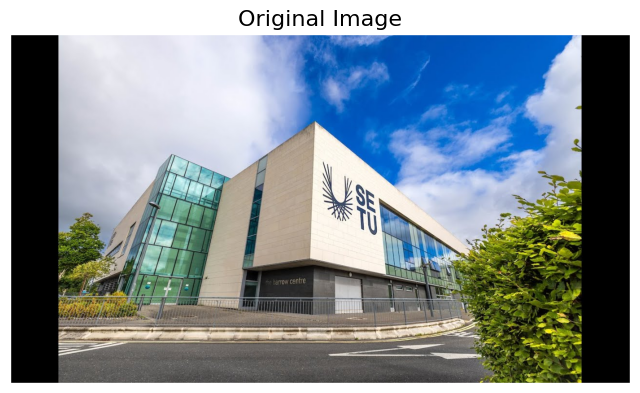

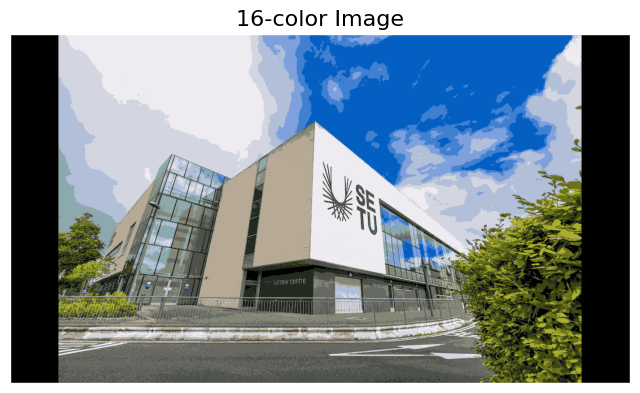

In [9]:
# First image: Original
fig1, ax1 = plt.subplots(figsize=(8, 6), subplot_kw=dict(xticks=[], yticks=[]))
ax1.imshow(carlowCampus)
ax1.set_title('Original Image', size=16)
plt.savefig("carlowCampus_original.png", format="png")

# Second image: 16-color compressed
fig2, ax2 = plt.subplots(figsize=(8, 6), subplot_kw=dict(xticks=[], yticks=[]))
ax2.imshow(carlowCampusCompressed)
ax2.set_title('16-color Image', size=16)
plt.savefig("carlowCampus_16color.png", format="png")

Using the os import, I was surprised to find the  16 colour image ended up being larger than the original image in jpeg format. Upon further research this is due to JPEG compression algorithm relying on smoother colour transitions.

Changing the image format to png reduced the memory size more drastically as png uses colour palettes, allowing it to use exactly the number of colour bits given.

In [10]:
import os

originaljpegSize = os.path.getsize('carlowCampus_original.jpg') / 1024
compressedjpegSize = os.path.getsize('carlowCampus_16color.jpg') / 1024

originalpngSize = os.path.getsize('carlowCampus_original.png') / 1024
compressedpngSize = os.path.getsize('carlowCampus_16color.png') / 1024

print(f"Original jpeg image size: {originaljpegSize:.2f} KB")
print(f"16-color jpeg image size: {compressedjpegSize:.2f} KB"'\n')

print(f"Original png image size: {originalpngSize:.2f} KB")
print(f"16-color png image size: {compressedpngSize:.2f} KB")


Original jpeg image size: 41.70 KB
16-color jpeg image size: 41.97 KB

Original png image size: 321.35 KB
16-color png image size: 235.11 KB
